<a href="https://colab.research.google.com/github/YasiruMethmal123/By-Which-House/blob/main/script/Housing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import sklearn.preprocessing as preprocessor

In [2]:
df = pd.read_csv('House_Price.csv')
df.head()

,Location,Size,Bedrooms,Price,Label
0,London,128.2,4,1379396,high
1,Los Angeles,340.5,5,2696965,high
2,Houston,51.9,2,411411,low
3,Houston,251.2,5,1465747,high
4,Rome,145.1,3,846075,low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Location  600 non-null    object 
 1   Size      600 non-null    float64
 2   Bedrooms  600 non-null    int64  
 3   Price     600 non-null    int64  
 4   Label     600 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 23.6+ KB


In [4]:
df.isna().sum()


,0
Location,0
Size,0
Bedrooms,0
Price,0
Label,0


In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
# class imbalance
df['Label'] = df['Label'].replace('low', 0)
df['Label'] = df['Label'].replace('medium', 1)
df['Label'] = df['Label'].replace('high', 2)



/tmp/ipykernel_3051/3551024022.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Label'] = df['Label'].replace('high', 2)


In [7]:
df['Label'].value_counts()

,count
Label,
2,300
0,300


# Exploatory Data Analysis

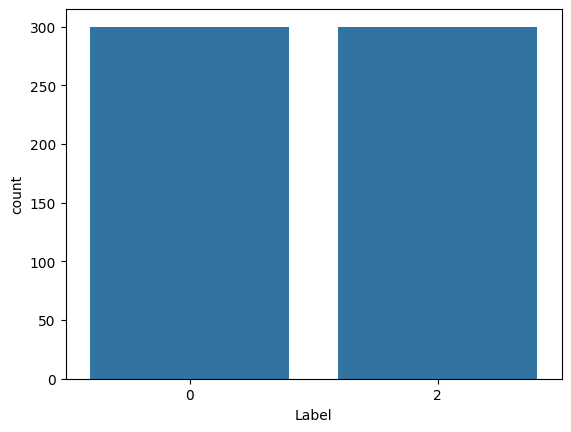

In [8]:
# plot class imbalance
sns.countplot(x='Label', data=df)
plt.show()

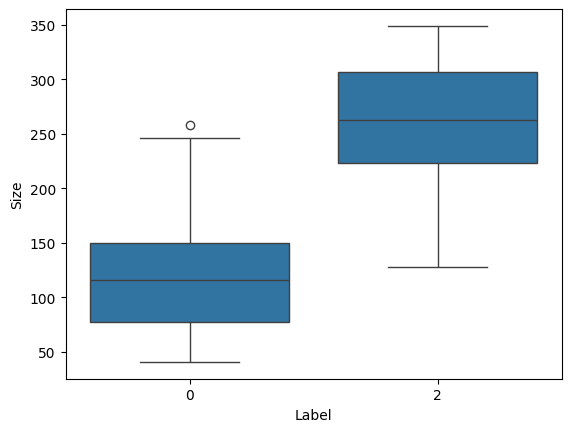

In [21]:
# box plot for relevent features
sns.boxplot(x='Label', y='Size', data=df)
plt.show()

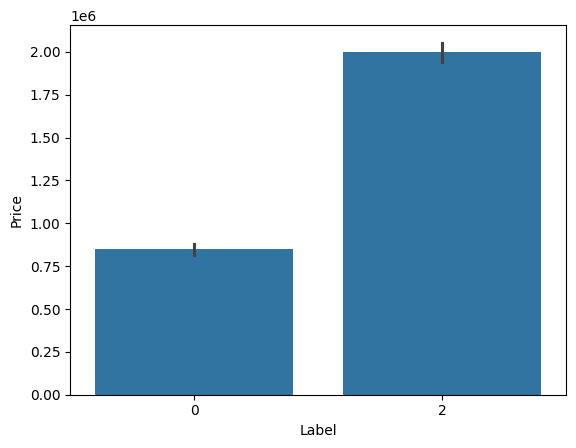

In [23]:
# bar graph for price and size
sns.barplot(x='Label', y='Price', data=df)
plt.show()

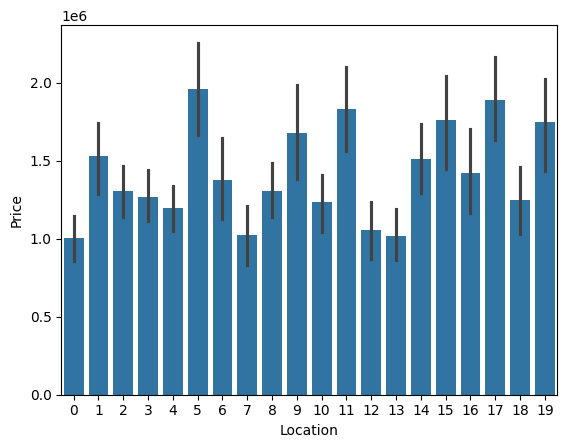

In [25]:
# location and price bar graph
sns.barplot(x='Location', y='Price', data=df)
plt.show()

# Preprocessing

In [10]:
# convert Location cloumn to numeric
le = preprocessor.LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])
df.head()

,Location,Size,Bedrooms,Price,Label
0,5,128.2,4,1379396,2
1,6,340.5,5,2696965,2
2,4,51.9,2,411411,0
3,4,251.2,5,1465747,2
4,13,145.1,3,846075,0


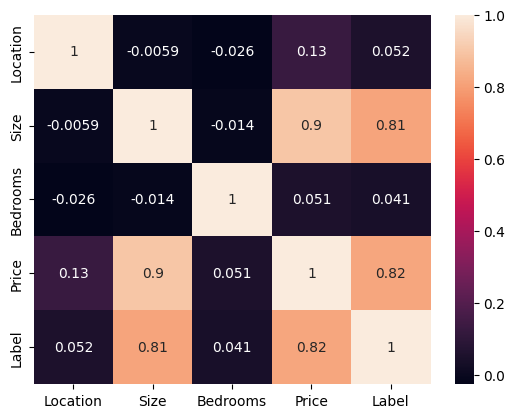

In [11]:
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [12]:
# split teh data into X_train and X_test y_train and y_test
from sklearn.model_selection import train_test_split
X = df.drop('Label', axis=1)
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
# scale the data
scaler = preprocessor.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# import svm for the train
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.975
[[56  0]
 [ 3 61]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        56
           2       1.00      0.95      0.98        64

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120



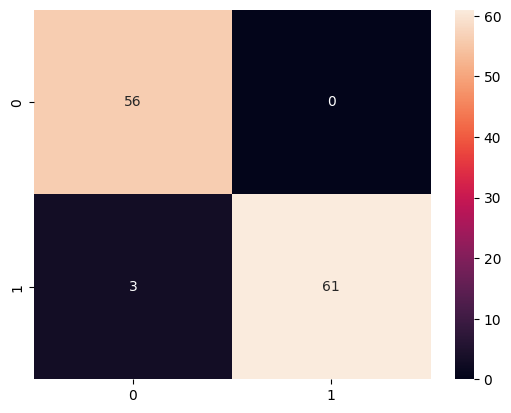

In [15]:
# confussion matrix plot
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()


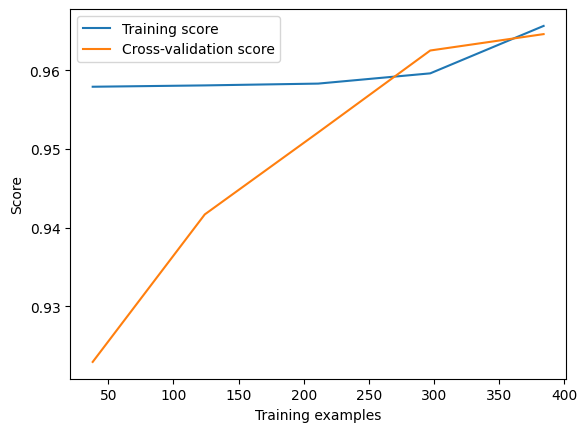

In [17]:
# learning curve plot
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend()

In [18]:
# cross validation to teh model
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=5)
print(scores)
print(scores.mean())

[0.95833333 0.97916667 0.98958333 0.91666667 0.97916667]
0.9645833333333333


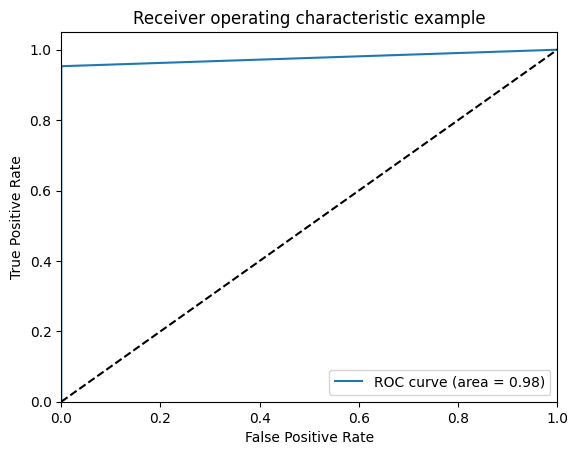

In [22]:
# ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=2)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# dump model , feature model , and scaler model
import joblib as jb
jb.dump(svm, 'svm.pkl')
jb.dump(scaler, 'scaler.pkl')
jb.dump(le, 'le.pkl')
#
